In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_ionic_interactions)=
# get_ionic_interactions
*Detecting minimum-distance observations between formal-charge centers.*

Use selected-state chemical participants and an explicit distance cutoff to
calculate a sparse analysis. This experimental method reports geometric
proximity, not an electrostatic energy or a declared bond.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.ionic.get_ionic_interactions` for the argument,
error, and result contracts.
:::

## Basic usage

Let's show how this function works with explicit formal-charge participants.
First inspect a bundled molecular system: coordinates and residue names alone
do not provide the state chemistry required by this method.

In [2]:
import molsysmt as msm

In [3]:
demo = msm.systems['pentalanine']['traj_pentalanine.h5msm']
try:
    msm.interactions.ionic.get_ionic_interactions(demo, '0.4 nm', pbc=False)
except msm.StructuralInconsistencyError:
    print('Explicit formal charges and complete bond chemistry are required.')

Explicit formal charges and complete bond chemistry are required.


:::{note} Demo Systems Catalog
:class: dropdown

This example uses {ref}`Demo Systems <user-foundations-entrance-demo-systems>`.
The clean failure above does not automatically parameterize or repair the system.
:::

Construct a small analytical ensemble containing sodium, chloride, and
potassium. The connectivity assumption is explicit: these isolated ions have
no covalent bonds. The 0.4 nm cutoff is chosen for this example, not supplied as
a universal scientific default.

In [4]:
import numpy as np
from molsysmt import pyunitwizard as puw
from molsysmt.native import MolSys, Topology

molsys = MolSys()
molsys.topology = Topology(n_atoms=3)
molsys.topology.atoms['atom_type'] = ['Na', 'Cl', 'K']
msm.set(molsys, element='atom', formal_charge=[1, -1, 1])
coordinates = np.array([
    [[0,0,0], [0.3,0,0], [0.6,0,0]],
    [[0,0,0], [2,0,0], [4,0,0]],
    [[0,0,0], [0.2,0,0], [0.8,0,0]],
])
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))

analysis = msm.interactions.ionic.get_ionic_interactions(
    molsys, '0.4 nm', pbc=False, assume_complete_connectivity=True)
print(analysis.n_interactions)
print(analysis.measurements['distance'])
print(analysis.measure_units)
assert analysis.n_interactions == 3
assert not molsys.interactions

3
[0.3 0.3 0.2]
{'distance': 'nm', 'positive_charge': 'e', 'negative_charge': 'e'}


## Choosing structures

Repeated structure indices are evaluated once in sorted order. A frame with
no occurrences remains evaluated; an omitted frame remains unevaluated.
All occurrence and participant indices address the original input system.

In [5]:
selected = msm.interactions.ionic.get_ionic_interactions(
    molsys, '0.4 nm', structure_indices=[2, 0, 2], pbc=False,
    assume_complete_connectivity=True)
print(selected.evaluated_structure_indices.tolist())
empty = analysis.query(structure_indices=[1]).to_dict()
print(empty['evaluated_structure_indices'].tolist())
print(empty['occurrence_indices'].tolist())
assert selected.evaluated_structure_indices.tolist() == [0, 2]
assert empty['evaluated_structure_indices'].tolist() == [1]

[0, 2]
[1]
[]


## Choosing calculation scope

`internal` searches only complete centers in the first selection. `incident`
searches interactions involving those centers with any eligible center in the
system, including internal contacts. `between` requires two disjoint selections.
The detector rejects selections that cut a nonzero compound center.

In [6]:
def calculate(**kwargs):
    return msm.interactions.ionic.get_ionic_interactions(
        molsys, '0.4 nm', pbc=False, assume_complete_connectivity=True, **kwargs)

internal = calculate(selection=[0, 1], selection_mode='internal')
incident = calculate(selection=[1], selection_mode='incident')
between = calculate(selection=[0, 2], selection_2=[1], selection_mode='between')
print(internal.n_interactions, incident.n_interactions, between.n_interactions)
assert (internal.n_interactions, incident.n_interactions, between.n_interactions) == (2, 3, 3)
print(analysis.query(structure_indices=[2], atom_indices=[0]).n_interactions)

2 3 3
1


## Inspecting variable occurrence counts

The counts below reflect this constructed ensemble. Zero is a valid result;
missing chemistry would instead raise an error.

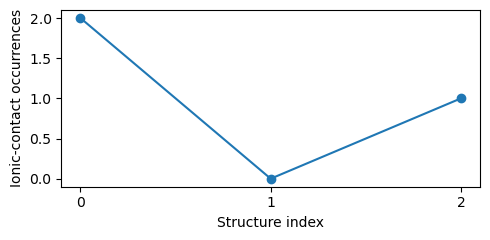

In [7]:
import matplotlib.pyplot as plt

counts = [analysis.query(structure_indices=[frame]).n_interactions for frame in range(3)]
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(range(3), counts, 'o-')
ax.set(xlabel='Structure index', ylabel='Ionic-contact occurrences', xticks=[0, 1, 2])
fig.tight_layout()
assert counts == [2, 0, 1]

## Measuring compound participants

Guanidinium and carboxylate illustrate charged groups found in arginine and
acidic residues. Here you use explicit small-molecule chemistry as an analogue,
with constructed coordinates rather than an experimental protein structure.
This optional preparation uses RDKit through the existing conversion route.

The positive participant includes the central carbon and three nitrogens;
the negative one includes its carbon and two oxygens. Minimum distances use
nitrogens and oxygens, respectively. Several close reference pairs still produce
one occurrence per center pair.

In [8]:
topology = msm.convert('smiles:NC(=[NH2+])N.CC(=O)[O-]', to_form='molsysmt.Topology')
molsys_A = msm.convert(topology, to_form='molsysmt.MolSys')
molsys_A.structures.append(coordinates=puw.quantity(np.array([[
    [0,0,0], [0,0.05,0], [0,-0.05,0], [0.05,0,0],
    [0.4,0,0], [0.3,0,0], [0.25,0,0], [0.35,0,0],
]]), 'nm'))
compound = msm.interactions.ionic.get_ionic_interactions(molsys_A, '0.4 nm', pbc=False)
print(compound.relation(0))
print(compound.measurements['distance'])
assert compound.n_interactions == 1
assert compound.query(atom_indices=[1], mode='incident').n_interactions == 1

{'interaction_type': 'ionic_contact', 'participants': [{'role': 'positive', 'atom_indices': array([0, 1, 2, 3])}, {'role': 'negative', 'atom_indices': array([5, 6, 7])}]}
[0.2]


## Choosing a chemical state

Recognition uses one state throughout the requested structures. Changing the
formal charges changes the chemical participants without changing coordinates.
The new state below declares all three isolated-ion sites neutral solely as an
analytical control. It is not an inferred physical transformation.

In [9]:
neutral_index = molsys.chemical_states.append_state()
msm.set(molsys, element='atom', chemical_state=neutral_index, formal_charge=[0, 0, 0])
neutral = calculate(chemical_state=neutral_index)
print(neutral.n_interactions, neutral.parameters['chemical_state_index'])
assert neutral.n_interactions == 0
assert calculate(chemical_state=0).n_interactions == 3

0 1


## Applying periodic images

When a box is present, the method uses MIC geometry. Add the reported lattice
vector multiplied by the row-vector box to every atom of the corresponding
participant. The positive participant is the reference image.

Compound participants must already be whole in the source coordinates under
the documented anchor-relative MIC condition. Split groups raise an explicit
error: reconstructing them silently would make their saved image ambiguous.

In [10]:
molsys_B = MolSys()
molsys_B.topology = Topology(n_atoms=2)
molsys_B.topology.atoms['atom_type'] = ['Na', 'Cl']
msm.set(molsys_B, element='atom', formal_charge=[1, -1])
xyz = np.array([[[0.1, 0, 0], [0.9, 0, 0]]])
box = np.eye(3)[None]
molsys_B.structures.append(coordinates=puw.quantity(xyz, 'nm'), box=puw.quantity(box, 'nm'))
periodic = msm.interactions.ionic.get_ionic_interactions(
    molsys_B, '0.4 nm', assume_complete_connectivity=True)
displayed = xyz[0] + periodic.image_vectors @ box[0]
print(periodic.image_vectors.tolist())
print(periodic.measurements['distance'])
assert np.isclose(np.linalg.norm(displayed[1] - displayed[0]), 0.2)

[[0, 0, 0], [-1, 0, 0]]
[0.2]


## Exporting and attaching results

The default result is an `Interactions` analysis. Request `InteractionsDict`
for its typed serialization payload, or use the public conversion. Attach a
result explicitly under a name; the detector leaves existing analyses intact.

In [11]:
dictionary = calculate(output_type='molsysmt.InteractionsDict')
restored = msm.convert(dictionary, to_form='molsysmt.Interactions')
molsys.interactions = {**molsys.interactions, 'ionic': analysis}
print(list(molsys.interactions))
print(restored.software)
assert restored.n_interactions == analysis.n_interactions

['ionic']
{'molsysmt': '0.21.0+606.ga03eb4bf6'}


## Calculating in blocks

`heavy_mode='auto'` chooses coordinate blocks when the source or selected-buffer
working estimate requires them. `force` requests blocks; `off` requests eager
execution within the budget. Chunked input supports native `MolSys` and H5MSM
0.5 paths with atom-index selections or `'all'`. Rich string selections use
the eager route and are rejected for forced chunking.

The following small example limits blocks to two structures. Scientific
observations and occurrence indices agree with the eager analysis. Execution
parameters record the path and actual number of blocks.


In [12]:
with msm.configure.context(chunk_size=2):
    chunked = calculate(heavy_mode='force')
    eager = calculate(heavy_mode='off')
np.testing.assert_array_equal(chunked.occurrence_structures, eager.occurrence_structures)
np.testing.assert_allclose(chunked.measurements['distance'], eager.measurements['distance'])
print(chunked.parameters['execution'], chunked.parameters['execution_chunks'])


chunked 2


## Understanding limits

The recognizer uses formal charges, bounded carboxyl/guanidine rules and
directly connected charged atoms. Atomic or generic cluster labels do not
resolve phosphate, sulfate or aromatic delocalization universally. Their
expansion is tracked by [MolSysMT #262](https://github.com/uibcdf/molsysmt/issues/262).
Intramolecular contacts are included; directly covalently linked centers are
excluded. Dative bonds do not impose that exclusion. Only one minimum-image
observation is returned per center pair, not every possible periodic image.

The calculation prepares chemistry once. For an H5MSM 0.5 input with index
selections, it loads topology, chemical states and association metadata while
reading only selected coordinate blocks and no saved analyses. These domains
must declare identity atom-axis links. A structure-assigned state must be the
same for all requested frames.

The complete sparse analysis remains in memory. Numerical working estimates
allocate one quarter of `max_ram_usage` to coordinate blocks, one eighth per
candidate search and one half to sparse accumulation/packing. A calculation
fails clearly when these estimates cannot fit; it does not return partial
coverage or silently switch methods. These estimates do not bound process RSS:
source coordinates, chemistry tables, Python objects and library overhead also
occupy RAM. Conservative candidate bounds can reject a small budget even when
actual neighbors would be sparse. No incremental result writer is provided.

The cutoff includes a one-float64-ULP allowance for unit-conversion roundoff.

:::{seealso} Related Tools & References
:class: dropdown

- {func}`molsysmt.basic.convert` — preparing supported forms and serializing results.
- {func}`molsysmt.physchem.get_charge_centers` — inspecting chemical participants.
- {ref}`Cookbook_Saving_ionic_interactions` — saving a named analysis with its system.
:::